# 04 — Side-by-side analysis, expert specialisation and verdict

Pulls together the runs from notebooks 01–03 (read from `results/*.json`; the same data lives in Aim).

* all runs in one table and one figure,
* what the experts actually learned to do (which tokens go where),
* the checklist that answers the assignment.

In [1]:
import sys, os, math, warnings

warnings.filterwarnings("ignore")
sys.path.insert(0, os.environ.get("MOE_SRC", os.path.abspath("../src")))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from moe.analysis import make_decoder, make_encoder
from moe.config import get_config
from moe.data import load_dataset_tokens
from moe.model import GPT, GPTConfig, MoEMLP, param_report
from moe.runs import dense_config, flops_per_token, moe_config, train_config
from moe.trainer import load_history, load_model, lr_at, train
from moe.upcycle import max_logit_diff, upcycle
from moe.utils import (
    aim_repo,
    ckpt_dir,
    get_device,
    is_smoke,
    plot_style,
    results_dir,
    savefig,
    set_seed,
    work_root,
)
from moe.viz import color, ema, heatmap_load

plot_style()
X = get_config()
DEVICE = get_device()
torch.set_float32_matmul_precision("high")
set_seed(X.seed)
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)

print(
    f"torch {torch.__version__} | device = {DEVICE}"
    + (
        f" ({torch.cuda.get_device_name(0)}, {torch.cuda.get_device_properties(0).total_memory / 1e9:.0f} GB)"
        if DEVICE == "cuda"
        else ""
    )
)
print(f"preset = {X.name!r}   (override with MOE_PRESET=smoke|small|base)")
print(f"Aim repo : {aim_repo()}   -> browse with:  uv run aim up")
print()
print(pd.Series(X.to_dict(), name="value").to_string())

torch 2.6.0+cu124 | device = cuda:1
preset = 'base'   (override with MOE_PRESET=smoke|small|base)
Aim repo : /home/ravi.naik/learning/era/ERA/v5/session14/moe_experiments   -> browse with:  uv run aim up

name                    base
vocab_size             50304
block_size               512
n_layer                    8
n_head                     8
n_embd                   512
dropout                  0.0
bias                    True
n_experts                  8
top_k                      2
moe_every                  2
score_fn             softmax
lb_coef               0.0001
bias_update            0.001
z_coef                 0.001
explore_steps            300
explore_noise            1.0
batch_size                32
dense_steps             6000
dense_lr              0.0006
dense_warmup             300
cont_steps              3000
cont_lr               0.0003
cont_warmup              100
min_lr_frac              0.1
weight_decay             0.1
eval_interval            250
eval_iters  

## 1. All runs

In [2]:
labels = ["dense", "moe_scratch", "dense_continue", "moe_upcycled"]
H = {}
for l in labels:
    try:
        H[l] = load_history(l)
    except FileNotFoundError:
        print(f"missing run '{l}' - run the earlier notebooks")
tok_step = X.batch_size * X.block_size
rows = {}
for l, h in H.items():
    rows[l] = {
        "phase": h["phase"],
        "steps": h["step"][-1] + 1 - h["step_offset"] if h["step"] else 0,
        "tokens (M)": (
            len(h["step"]) and (h["step"][-1] + 1 - h["step_offset"]) * tok_step / 1e6
        ),
        "params (M)": h["n_params"] / 1e6,
        "active (M)": h["n_active_params"] / 1e6,
        "final val": h["final_val_loss"],
        "val ppl": math.exp(h["final_val_loss"]),
        "min/run": h["wall_clock_s"] / 60,
        "k tok/s": np.mean(h["tok_s"][1:]) / 1e3,
        "peak GB": h["peak_mem_gb"],
    }
print(pd.DataFrame(rows).T.round(3).to_string())

                         phase steps tokens (M)  params (M) active (M) final val    val ppl    min/run     k tok/s peak GB
dense                    dense  6000     98.304   51.213824  51.213824  3.626928  37.597128  25.449304   82.846907     0.0
moe_scratch        moe_scratch  6000     98.304  110.022144  59.629056   3.53142  34.172468  32.752137   65.385824     0.0
dense_continue  dense_continue  3000     49.152   51.213824  51.213824  3.521254  33.826824   8.175568  112.970402     0.0
moe_upcycled      moe_upcycled  3000     49.152  110.022144  59.629056  3.501921  33.179132  11.484388   79.624155     0.0


> **Reading this table.** `peak GB = 0.0` is the device-query bug described in notebook 01 (not a measurement). `k tok/s` is a *mean*; the dense pre-training run was disturbed
> (median 60 k/s), so only the two continuation runs (dense 116 k vs MoE 82 k median tokens/s, ≈ 0.71×) are directly comparable. `tokens (M)` counts each run's own steps; the continuation runs sit on top of the 98.3 M-token pre-training.

  saved assets/04_all_runs.png


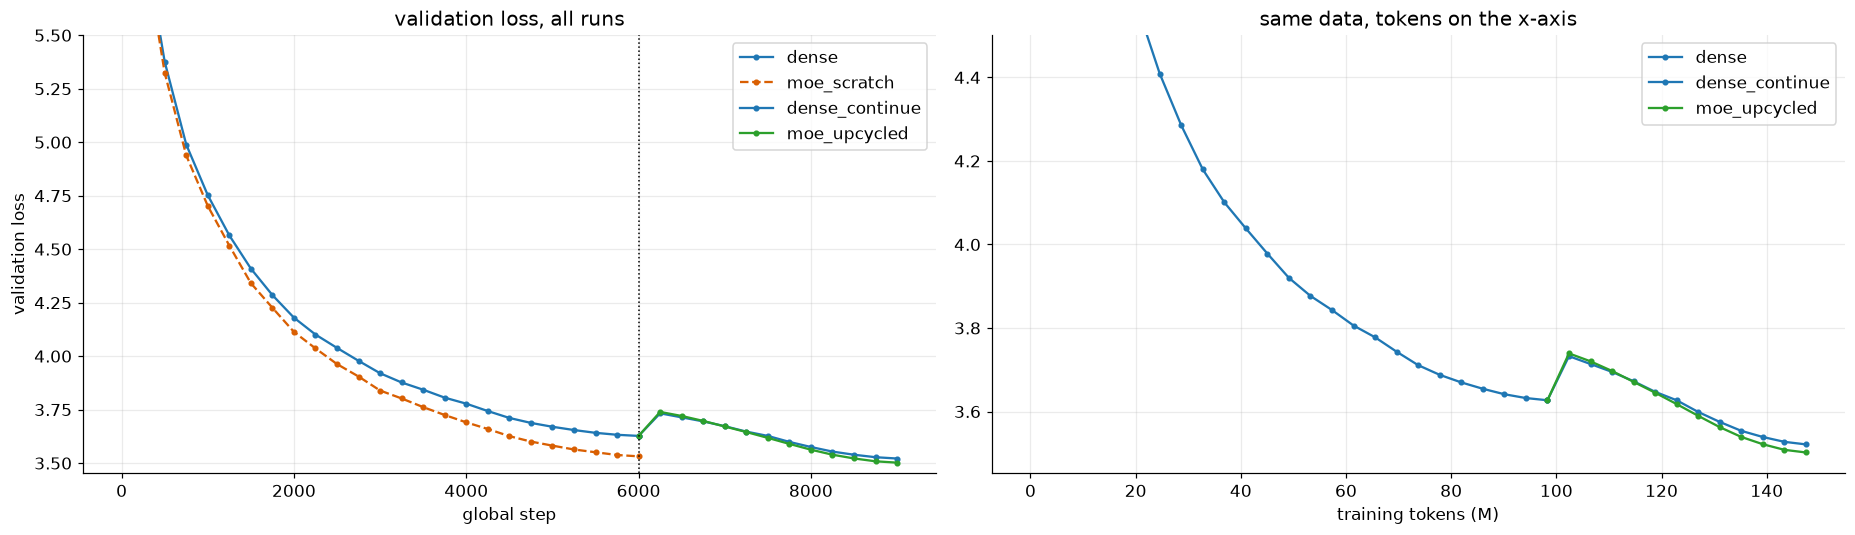

In [3]:
fig, axs = plt.subplots(1, 2, figsize=(17, 5))
ax = axs[0]
for l, h in H.items():
    ax.plot(
        h["eval_step"],
        h["val_loss"],
        "o-",
        ms=3,
        color=color(l),
        label=l,
        ls="-" if l != "moe_scratch" else "--",
    )
ax.axvline(X.dense_steps, color="k", ls=":", lw=1)
ax.set_xlabel("global step")
ax.set_ylabel("validation loss")
ax.set_title("validation loss, all runs")
ax.legend()
lo = min(min(h["val_loss"]) for h in H.values())
ax.set_ylim(lo - 0.05, lo + 2.0)

ax = axs[1]
for l, h in H.items():
    if l in ("dense_continue", "moe_upcycled", "dense"):
        x = (np.array(h["eval_step"]) * tok_step) / 1e6
        ax.plot(x, h["val_loss"], "o-", ms=3, color=color(l), label=l)
ax.set_xlabel("training tokens (M)")
ax.set_title("same data, tokens on the x-axis")
ax.legend()
ax.set_ylim(lo - 0.05, lo + 1.0)
plt.tight_layout()
savefig(fig, "04_all_runs.png")
plt.show()

## 2. What did the experts learn?

We run the upcycled MoE over held-out text and record each token's top-1 expert. If routing were meaningless
(experts remained clones), every expert would see the same token distribution. *Lift* = P(token | expert) / P(token): values ≫ 1 mean the expert is
specialised on that token.

In [4]:
from moe.analysis import collect_routing, expert_similarity

path = os.path.join(ckpt_dir(), "moe_upcycled.pt")
assert os.path.exists(path), "run notebook 03 first"
data = load_dataset_tokens(X.dataset)
model = load_model(path, DEVICE)
dec = make_decoder(X.dataset)
nbatch = 4 if is_smoke() else 40
R = collect_routing(model, data, nbatch, X.batch_size, X.block_size, DEVICE)
toks, top1 = R["tokens"], R["top1"]
print(f"routed {len(toks):,} validation tokens through {top1.shape[0]} MoE layers")
E = X.n_experts
base_counts = np.bincount(toks, minlength=X.vocab_size) / len(toks)

for li in range(top1.shape[0]):
    print(f"\n=========== MoE layer {li} (block {R['layers'][li]}) ===========")
    rows = []
    for e in range(E):
        m = top1[li] == e
        n = int(m.sum())
        if n == 0:
            rows.append({"expert": e, "share": 0.0, "top tokens (lift)": "(unused)"})
            continue
        c = np.bincount(toks[m], minlength=X.vocab_size) / n
        score = c / np.maximum(base_counts, 1e-12) * (c > 0)
        cand = np.argsort(-c)[:40]  # frequent in this expert...
        best = sorted(cand, key=lambda t: -score[t])[:6]  # ...ordered by lift
        rows.append(
            {
                "expert": e,
                "share": n / len(toks),
                "top tokens (lift)": "  ".join(
                    f"{dec([t])!r}x{score[t]:.1f}" for t in best
                ),
            }
        )
    print(pd.DataFrame(rows).round(3).to_string(index=False))

[data] cached wikitext103: 119,085,169 train / 249,750 val tokens
routed 655,360 validation tokens through 4 MoE layers

=========== MoE layer 0 (block 1) ===========
 expert  share                                                                        top tokens (lift)
      0  0.154                   ' Rad'x6.4  ' Tik'x5.9  ' Churchill'x5.6  ' �'x5.1  'al'x4.9  ' I'x4.7
      1  0.162                       ' her'x4.9  ' 18'x4.8  ' back'x4.8  ' an'x4.7  ' she'x4.7  '-'x4.7
      2  0.143 ' Army'x7.0  ' Richmond'x6.4  ' series'x6.3  ' held'x6.2  ' government'x6.1  ' team'x6.0
      3  0.237                       'y'x4.1  ' ='x3.8  ' along'x3.7  ' from'x3.5  ' St'x3.3  ' or'x3.2
      4  0.150                    ' made'x6.3  ' only'x6.1  ' As'x6.1  ' under'x5.7  ' R'x5.5  ' B'x5.2
      5  0.101        ' @'x8.7  ' did'x7.7  ' She'x7.1  ' performance'x6.7  ' video'x6.4  ' United'x6.3
      6  0.034         ' ...'x28.6  ' critics'x21.6  ' "'x19.6  ' others'x19.3  ' fire'x14.4  ' !'x12.2
 

  saved assets/04_expert_token_types.png


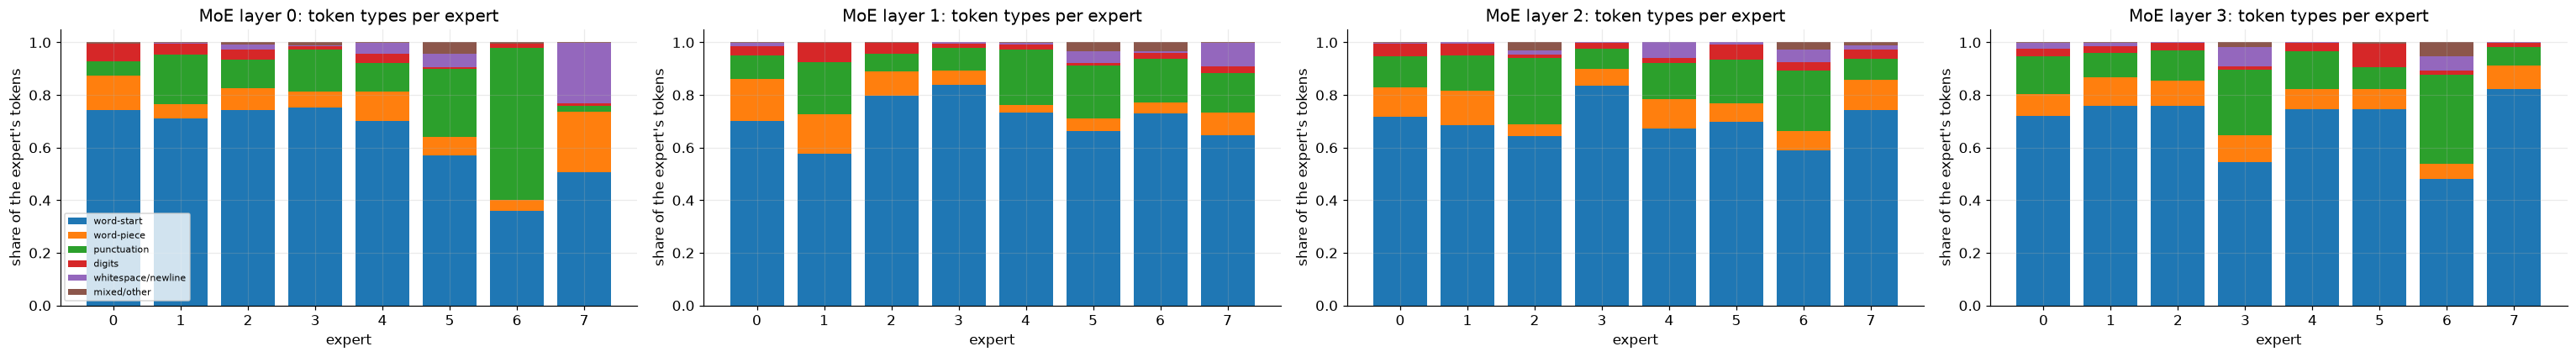

overall token-type mix: {'word-start': 0.698, 'punctuation': 0.155, 'word-piece': 0.086, 'digits': 0.032, 'whitespace/newline': 0.02, 'mixed/other': 0.01}


In [5]:
def category(s: str) -> str:
    if s.strip() == "":
        return "whitespace/newline"
    t = s.strip()
    if t.isdigit():
        return "digits"
    if t.isalpha():
        return "word-start" if s.startswith(" ") else "word-piece"
    if not any(ch.isalnum() for ch in t):
        return "punctuation"
    return "mixed/other"


cats = [
    "word-start",
    "word-piece",
    "punctuation",
    "digits",
    "whitespace/newline",
    "mixed/other",
]
cat_of = {int(t): category(dec([t])) for t in np.unique(toks)}
cat_arr = np.array([cat_of[int(t)] for t in toks])
fig, axs = plt.subplots(1, top1.shape[0], figsize=(7 * top1.shape[0], 4), squeeze=False)
for li in range(top1.shape[0]):
    ax = axs[0, li]
    bottom = np.zeros(E)
    for c in cats:
        frac = np.array(
            [
                (cat_arr[top1[li] == e] == c).mean() if (top1[li] == e).any() else 0
                for e in range(E)
            ]
        )
        ax.bar(range(E), frac, bottom=bottom, label=c)
        bottom += frac
    ax.set_title(f"MoE layer {li}: token types per expert")
    ax.set_xlabel("expert")
    ax.set_ylabel("share of the expert's tokens")
    if li == 0:
        ax.legend(fontsize=7, loc="lower left")
plt.tight_layout()
savefig(fig, "04_expert_token_types.png")
plt.show()
overall = pd.Series(cat_arr).value_counts(normalize=True).round(3)
print("overall token-type mix:", overall.to_dict())

### What we saw — what the experts specialise in

Routing was recorded on 655 k validation tokens. Specialisation is **weak and mostly about token type / syntax, not subject matter**:

* Layer 0, expert 6 (3 % of tokens) collects `' ...'`, `'"'`, `' !'`, `' critics'`, `' others'` (lift 12–29×); expert 7 (2 %) collects rare sub-word fragments (lift ≈ 50×). Small, sharply defined "tail" experts.
* Layer 1: expert 5 takes structural tokens (`' ='`, `<|endoftext|>`, `' This'`, `' The'`); expert 6 takes connectives (`' including'`, `' included'`, `' while'`, `' After'`, `' many'`).
* Most experts have broad, mixed lists with lift of only 4–7×: they share the work rather than divide it by topic. Lift on rare tokens is noisy at this sample size, so individual entries should not be over-read.

## 3. Verdict

In [6]:
d, up_, dc = H.get("dense"), H.get("moe_upcycled"), H.get("dense_continue")
ms = H.get("moe_scratch")
print("CHECKLIST")
print("-" * 78)
if d and up_:
    delta0 = up_["val_loss"][0] - d["final_val_loss"]
    print(
        f"[{'x' if abs(delta0) < 1e-3 else ' '}] conversion is lossless:      MoE loss at conversion {up_['val_loss'][0]:.4f} vs dense {d['final_val_loss']:.4f} (Δ {delta0:+.5f})"
    )
    print(
        f"[{'x' if up_['final_val_loss'] < up_['val_loss'][0] else ' '}] MoE keeps training:          {up_['val_loss'][0]:.4f} -> {up_['final_val_loss']:.4f} over {X.cont_steps} steps"
    )
    if dc:
        print(
            f"[{'x' if up_['final_val_loss'] < dc['final_val_loss'] else ' '}] MoE beats dense control:     {up_['final_val_loss']:.4f} vs {dc['final_val_loss']:.4f} ({up_['final_val_loss'] - dc['final_val_loss']:+.4f})"
        )
if up_:
    print(
        f"[{'x' if up_['dead_experts'][-1] == 0 else ' '}] no dead experts at the end:  {up_['dead_experts'][-1]} dead"
    )
    off = [s[~np.eye(len(s), dtype=bool)].mean() for s in expert_similarity(model)]
    print(
        f"[{'x' if max(off) < 0.9999 else ' '}] experts diverged from clones: mean cosine sim per layer {np.round(off, 5).tolist()}"
    )
if ms and d:
    print(
        f"[i] MoE from scratch vs dense (same budget): {ms['final_val_loss']:.4f} vs {d['final_val_loss']:.4f} ({ms['final_val_loss'] - d['final_val_loss']:+.4f})"
    )
print("-" * 78)
print(
    "Browse everything interactively:  uv run aim up   (experiments: session14, session14_ablations)"
)

CHECKLIST
------------------------------------------------------------------------------
[x] conversion is lossless:      MoE loss at conversion 3.6269 vs dense 3.6269 (Δ -0.00000)
[x] MoE keeps training:          3.6269 -> 3.5019 over 3000 steps
[x] MoE beats dense control:     3.5019 vs 3.5213 (-0.0193)
[x] no dead experts at the end:  0 dead
[x] experts diverged from clones: mean cosine sim per layer [0.9283900260925293, 0.9303500056266785, 0.9261000156402588, 0.9333999752998352]
[i] MoE from scratch vs dense (same budget): 3.5314 vs 3.6269 (-0.0955)
------------------------------------------------------------------------------
Browse everything interactively:  uv run aim up   (experiments: session14, session14_ablations)


### Verdict

All five automatic checks pass, with the caveats written next to each result in notebooks 01–03:

1. **The conversion is lossless** (Δ loss 0.00000) — by construction, and verified.
2. **The MoE keeps training and reduces loss** after conversion: 3.627 → 3.502 over 3,000 steps (after a re-warm bump that the dense control shares).
3. **It beats continuing the dense model** by 0.019 nats at equal tokens (single seed), reaching the control's final loss after 2,507 rather than 3,000 steps.
4. **No expert is dead at the end**, after a transient early scare.
5. **The experts diverged** from their shared starting point (cosine 0.93, drift ≈ 28 %).

Not shown: a compute- or wall-clock-matched win. At equal *tokens* the MoE is better; at equal *time* on this implementation the dense model is ahead (the continuation took 11.5 vs 8.2 min, and even the 2,507 steps the MoE needs ≈ 9.6 min), because experts are executed in a Python loop rather than a grouped GEMM kernel.